# Expansiones Multipolares y Funciones Especiales en Cosmología

**Métodos Matemáticos — Taller Bono Individual**

Notebook en **Julia**. Reproduce todas las figuras del informe:
armónicos esféricos individuales, comparación de campos dominados por
multipolos bajos y altos, un campo sintético tipo CMB, y las funciones
de Neumann $N_0, N_1, N_2$.

Repositorio: https://github.com/Imaravel/BonoMetMat.git

## 0. Paquetes

Sólo se usan paquetes estándar del ecosistema Julia:
`Plots` (gráficas) y `SpecialFunctions` (funciones de Bessel/Neumann).
Los armónicos esféricos se calculan con una recurrencia propia, sin
dependencias adicionales.

In [1]:
# Ejecutar UNA vez para instalar los paquetes:
import Pkg
Pkg.add(["Plots", "SpecialFunctions"])

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.11/Project.toml`
  [276daf66] + SpecialFunctions v2.7.2
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [2]:
using Plots
using SpecialFunctions
using Printf
gr()                         # backend ligero
default(size=(800, 420), dpi=150)

## 1. Armónicos esféricos reales


In [3]:
# Función asociada de Legendre
function Plm(l::Int, m::Int, x::Float64)
    @assert 0 <= m <= l
    pmm = 1.0
    if m > 0
        somx2 = sqrt((1.0 - x) * (1.0 + x))
        fact = 1.0
        for _ in 1:m
            pmm *= -fact * somx2
            fact += 2.0
        end
    end
    l == m && return pmm
    pmmp1 = x * (2m + 1) * pmm
    l == m + 1 && return pmmp1
    pll = 0.0
    for ll in (m + 2):l
        pll = ((2ll - 1) * x * pmmp1 - (ll + m - 1) * pmm) / (ll - m)
        pmm = pmmp1
        pmmp1 = pll
    end
    return pll
end

# Constante de normalización
function Nlm(l::Int, m::Int)
    am = abs(m)
    return sqrt((2l + 1) / (4pi) * factorial(big(l - am)) / factorial(big(l + am))) |> Float64
end

# Armónico esférico real
function realY(l::Int, m::Int, theta::Float64, phi::Float64)
    x = cos(theta)
    if m > 0
        return sqrt(2.0) * Nlm(l, m) * Plm(l, m, x) * cos(m * phi)
    elseif m < 0
        am = -m
        return sqrt(2.0) * Nlm(l, am) * Plm(l, am, x) * sin(am * phi)
    else
        return Nlm(l, 0) * Plm(l, 0, x)
    end
end

realY (generic function with 1 method)

### 1.1 Proyección de Mollweide



In [4]:
# Rasteriza un campo f(theta, phi) en proyección de Mollweide.
# f recibe (theta=colatitud, phi in [0,2pi]) y devuelve un escalar.
function mollweide(f; nx::Int=400, ny::Int=200)
    xs = range(-2.0, 2.0, length=nx)      # X reescalado a [-2,2]
    ys = range(-1.0, 1.0, length=ny)      # Y reescalado a [-1,1]
    Z = fill(NaN, ny, nx)
    for (j, Y) in enumerate(ys), (i, X) in enumerate(xs)
        (abs(Y) > 1.0) && continue
        ta = asin(Y)                       # ángulo auxiliar (theta_aux)
        lat = asin((2ta + sin(2ta)) / pi)  # latitud
        coslat_aux = cos(ta)
        coslat_aux == 0 && continue
        lon = pi * X / (2 * coslat_aux)    # longitud en [-pi,pi]
        (abs(lon) > pi) && continue
        theta = pi/2 - lat                 # colatitud
        phi = lon + pi                     # [0, 2pi]
        Z[j, i] = f(theta, phi)
    end
    return xs, ys, Z
end

# Mapa de color tipo CMB (azul frío -> rojo caliente)
cmb_cmap = cgrad(:RdBu, rev=true)

function plot_field(f; title="", nx=400, ny=200, clim=nothing)
    xs, ys, Z = mollweide(f; nx=nx, ny=ny)
    vmax = clim === nothing ? maximum(abs, filter(!isnan, Z)) : clim
    heatmap(xs, ys, Z; c=cmb_cmap, clims=(-vmax, vmax),
            aspect_ratio=1, axis=false, grid=false, colorbar=true,
            title=title, background_color=:white)
end

plot_field (generic function with 1 method)

### 1.2 (Ítem III.a) Armónicos esféricos individuales



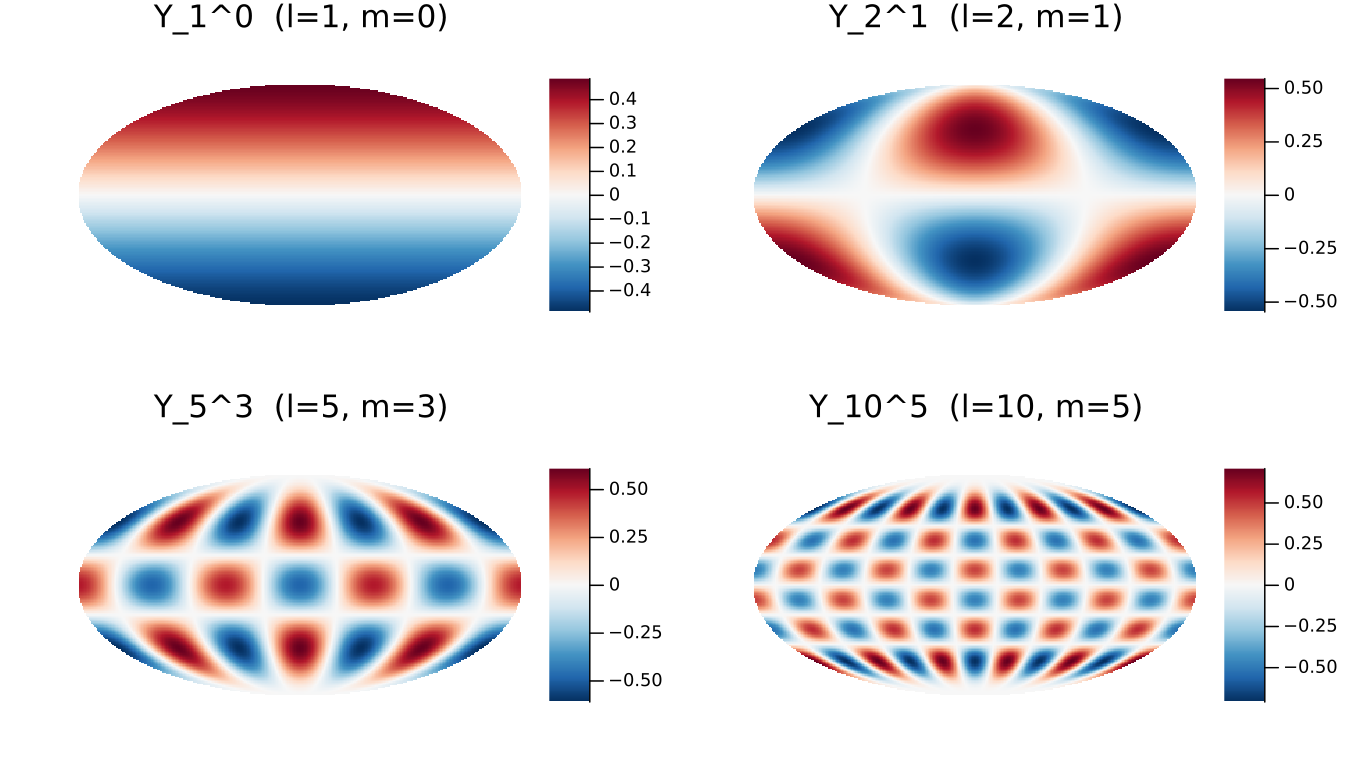

In [5]:
modos = [(1,0), (2,1), (5,3), (10,5)]
plts = []
for (l, m) in modos
    p = plot_field((th,ph) -> realY(l, m, th, ph);
                   title="Y_$(l)^$(m)  (l=$l, m=$m)", nx=320, ny=160)
    push!(plts, p)
end
fig1 = plot(plts...; layout=(2,2), size=(900, 520))
savefig(fig1, "sph_individual.png")
fig1

### 1.3 (Ítem III.b) Multipolos bajos vs. altos



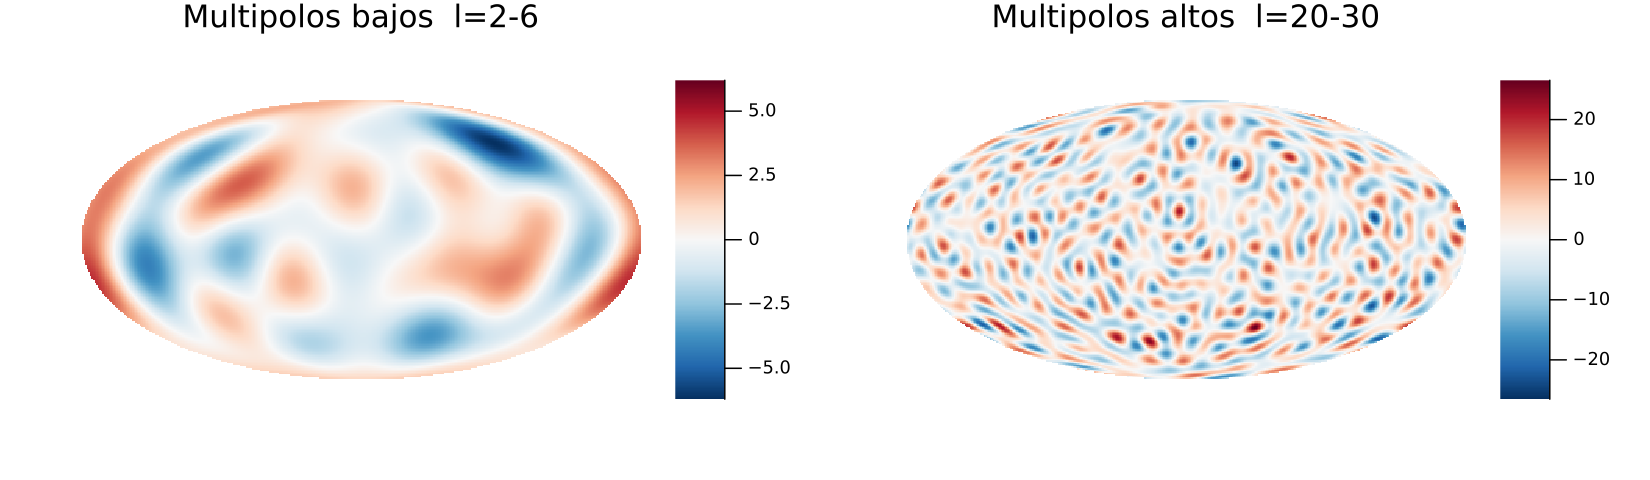

In [6]:
using Random
Random.seed!(2024)

# Campo aleatorio sumando multipolos en el rango [lmin, lmax]
function random_field(lmin, lmax)
    coef = Dict{Tuple{Int,Int},Float64}()
    for l in lmin:lmax, m in -l:l
        coef[(l,m)] = randn()
    end
    return (th, ph) -> sum(coef[(l,m)] * realY(l, m, th, ph)
                           for l in lmin:lmax for m in -l:l)
end

bajos = random_field(2, 6)
altos = random_field(20, 30)

pb = plot_field(bajos; title="Multipolos bajos  l=2-6", nx=360, ny=180)
pa = plot_field(altos; title="Multipolos altos  l=20-30", nx=360, ny=180)
fig2 = plot(pb, pa; layout=(1,2), size=(1100, 320))
savefig(fig2, "cmb_low_vs_high.png")
fig2

### 1.4 (Ítem III.c) Campo sintético tipo CMB


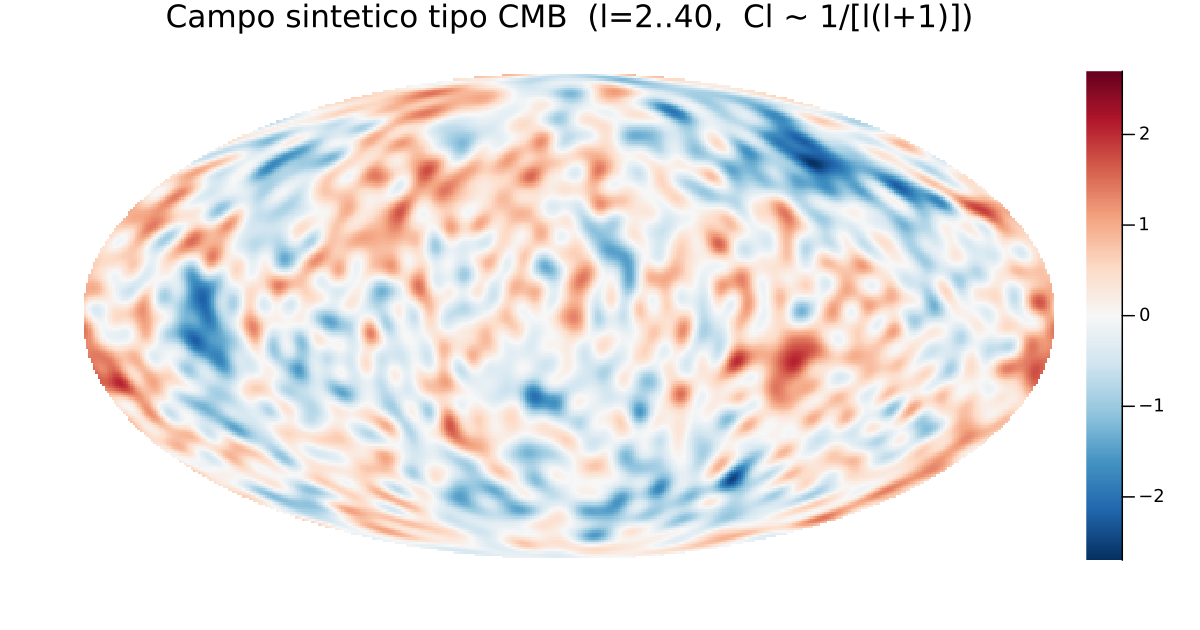

In [7]:
Random.seed!(2024)
lmax = 40
coef = Dict{Tuple{Int,Int},Float64}()
for l in 2:lmax
    Cl = 1.0 / (l * (l + 1.0))
    for m in -l:l
        coef[(l,m)] = randn() * sqrt(Cl)
    end
end
cmb_field = (th, ph) -> sum(coef[(l,m)] * realY(l, m, th, ph)
                            for l in 2:lmax for m in -l:l)

fig3 = plot_field(cmb_field;
        title="Campo sintetico tipo CMB  (l=2..$lmax,  Cl ~ 1/[l(l+1)])",
        nx=420, ny=210)
savefig(fig3, "cmb_synthetic.png")
fig3

## 2. Funciones $N_n(x)$



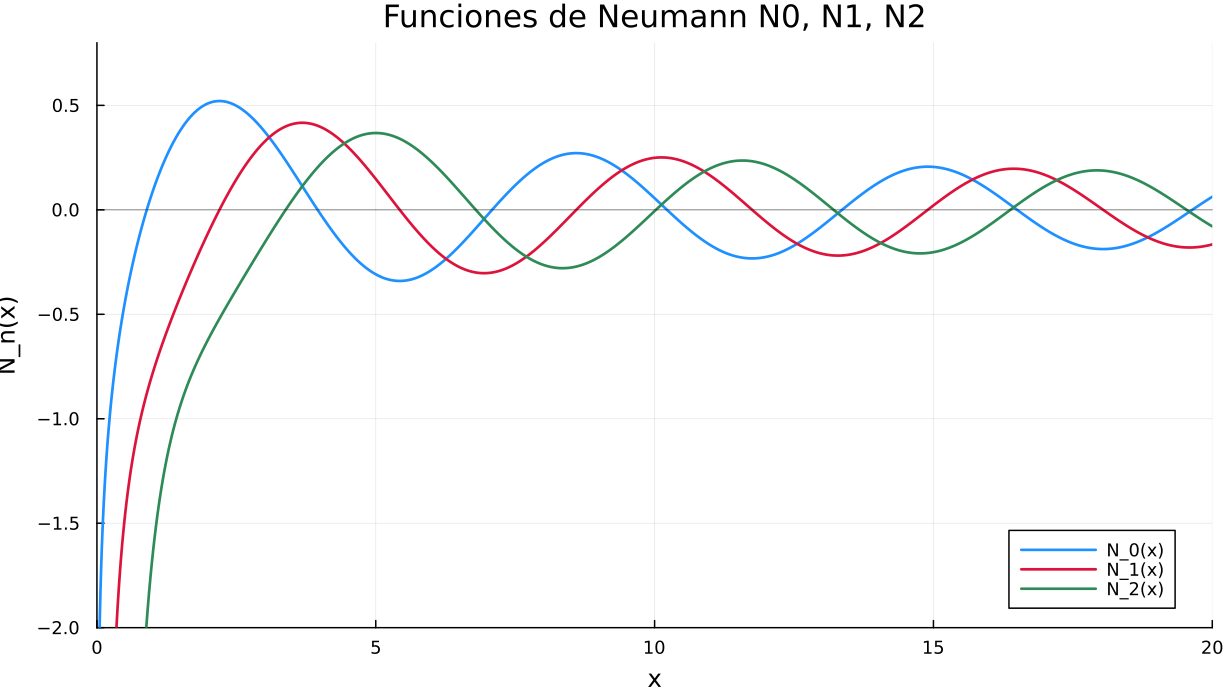

In [8]:
# (Item 2.a) Graficar N0, N1, N2 en 0.01 <= x <= 20
x = range(0.01, 20.0, length=4000)
colores = [:dodgerblue, :crimson, :seagreen]
figN = plot(size=(820, 460), xlabel="x", ylabel="N_n(x)",
            title="Funciones de Neumann N0, N1, N2",
            legend=:bottomright, ylims=(-2.0, 0.8), xlims=(0, 20))
for n in 0:2
    plot!(figN, x, bessely.(n, x), lw=1.8, color=colores[n+1], label="N_$n(x)")
end
hline!(figN, [0.0], color=:black, lw=0.6, alpha=0.5, label="")
savefig(figN, "neumann.png")
figN

### 2.b Comportamiento numérico

    

In [9]:
println("Valores cerca de x = 0 (divergencia a -inf):")
@printf("  N0(0.01) = %.4f\n", bessely(0, 0.01))
@printf("  N1(0.01) = %.4f\n", bessely(1, 0.01))
@printf("  N2(0.01) = %.4f\n", bessely(2, 0.01))

# Ceros aproximados (cambios de signo) de N0 y N1
function ceros(n)
    xs = collect(range(0.01, 20.0, length=20000))
    vals = bessely.(n, xs)
    z = Float64[]
    for i in 1:length(xs)-1
        if vals[i] * vals[i+1] < 0
            push!(z, (xs[i] + xs[i+1]) / 2)
        end
    end
    return z
end
println("\nPrimeros ceros de N0: ", round.(ceros(0)[1:4], digits=3))
println("Primeros ceros de N1: ", round.(ceros(1)[1:4], digits=3))

Valores cerca de x = 0 (divergencia a -inf):
  N0(0.01) = -3.0055
  N1(0.01) = -63.6786
  N2(0.01) = -12732.7138

Primeros ceros de N0: [0.893, 3.958, 7.086, 10.222]
Primeros ceros de N1: [2.198, 5.43, 8.596, 11.749]
